# Part B · NB4 — DINOv2   ·  `pavecrack1300-partb-dinov2`

**Course:** CSE 438 — Digital Image Processing · Dept. of CSE, **East West University** · Summer 2026
**Instructor:** _`Mohammad Rifat Ahmmad Rashid`_ · **Group:** _`<C>`_ · **Section:** _`<4>`_

| # | Name | Student ID |
|---|---|---|
| 1 | Mantasha Rahman Mahi | 2022-3-60-194 |
| 2 | Jannatul Ferdous Nabila | 2022-3-60-198 | 
| 3 | Nazratan Mazumder Niha | 2022-3-60-328 | 
| 4 | Sabiha Nusrat | 2022-1-60-303 |

**Method:** **DINOv2** — self-distillation (student/teacher) · backbone **ViT-S/14**.
**Pipeline (Part B):** SSL-pretrain the encoder on the Part-A **train** split (unlabelled, 50 ep) → attach the
Part-A best decoder (**DeepLabV3 ASPP head**) → fine-tune on the Part-A **val** split (195 labelled, 50 ep) →
monitor + evaluate on the Part-A **test** split. *(# debugged/authored with AI assistance where noted.)*

**Attach:** raw **PaveCrack1300** + committed **Part-B data-prep output** (`partB_roles.json`). **GPU (T4) ON.**

In [1]:
# ---- setup & imports (version-pinned) ----
import os, gc, json, glob, time, math, random, copy, warnings
from pathlib import Path
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")
try:
    import albumentations as A
    from albumentations.pytorch import ToTensorV2
except Exception:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "albumentations"], check=False)
    import albumentations as A
    from albumentations.pytorch import ToTensorV2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()
print("torch", torch.__version__, "| device", DEVICE, "| GPU:",
      torch.cuda.get_device_name(0) if DEVICE == "cuda" else "-")

def amp_ctx():
    return torch.autocast("cuda", enabled=(DEVICE == "cuda"))
try:
    scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE == "cuda"))
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE == "cuda"))

torch 2.10.0+cu128 | device cuda | GPU: Tesla T4


In [2]:
# ---- load Part-B role mapping (from data-prep) + resolve raw paths ----
def _find(p):
    h = glob.glob(p, recursive=True); return h[0] if h else None
PB = json.load(open(_find("/kaggle/input/**/partB_roles.json")))
IMG_SIZE = PB["resolution"]; NUM_CLASSES = PB["num_classes"]; CLASS_NAMES = PB["class_names"]
train_recs, val_recs, test_recs = PB["train"], PB["val"], PB["test"]
print("roles:", PB["counts"], "| label-efficiency", PB["label_efficiency_ratio"])

IMGS  = glob.glob("/kaggle/input/**/images/images/*.jpg", recursive=True) or \
        glob.glob("/kaggle/input/**/images/**/*.jpg", recursive=True)
MASKS = glob.glob("/kaggle/input/**/masks/**/*.png", recursive=True)
PATH_BY_NAME = {Path(p).name: p for p in IMGS}
MASK_BY_NAME = {Path(p).name: p for p in MASKS}
assert PATH_BY_NAME and MASK_BY_NAME, "attach the raw PaveCrack1300 dataset"
WORK = Path("/kaggle/working"); WORK.mkdir(exist_ok=True)
IMAGENET_MEAN = (0.485, 0.456, 0.406); IMAGENET_STD = (0.229, 0.224, 0.225)

roles: {'train': 909, 'val': 195, 'test': 196} | label-efficiency 0.2145


In [3]:
# ---- datasets: SSL two-view (images only) · labelled seg · test ----
def _try(cls, *vs):
    last = None
    for kw in vs:
        try: return cls(**kw)
        except (TypeError, ValueError) as e: last = e
    raise RuntimeError(str(last))
import cv2
def _geom(p=0.5):
    if hasattr(A, "ShiftScaleRotate"):
        try: return A.ShiftScaleRotate(0.0625, 0.1, 15, border_mode=cv2.BORDER_REFLECT_101, p=p)
        except (TypeError, ValueError): pass
    return _try(A.Affine, dict(translate_percent=0.0625, scale=(0.9,1.1), rotate=(-15,15), p=p))

label_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.HorizontalFlip(0.5), A.VerticalFlip(0.5),
                      A.RandomRotate90(0.5), _geom(0.5), A.RandomBrightnessContrast(0.2, 0.2, p=0.5),
                      A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])
test_tf = A.Compose([A.Resize(IMG_SIZE, IMG_SIZE), A.Normalize(IMAGENET_MEAN, IMAGENET_STD), ToTensorV2()])

class LabeledSeg(Dataset):
    def __init__(self, recs, aug): self.recs, self.aug = recs, aug
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        r = self.recs[i]
        img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        m = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype("uint8")
        o = self.aug(image=img, mask=m); return o["image"], o["mask"].long(), r["sample_id"]

class SSLTwoView(Dataset):
    def __init__(self, recs, tf): self.recs, self.tf = recs, tf
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        img = Image.open(PATH_BY_NAME[self.recs[i]["image"]]).convert("RGB")
        return self.tf(img), self.tf(img)

val_loader  = DataLoader(LabeledSeg(val_recs,  label_tf), batch_size=8,  shuffle=True,  num_workers=2, drop_last=False)
test_loader = DataLoader(LabeledSeg(test_recs, test_tf),  batch_size=8,  shuffle=False, num_workers=2)
print("labelled(val):", len(val_recs), "| test:", len(test_recs), "| unlabelled(train):", len(train_recs))

labelled(val): 195 | test: 196 | unlabelled(train): 909


In [4]:
# ---- metrics + loss (same confusion-matrix source of truth as Part A) ----
class ConfMat:
    def __init__(s, n): s.n = n; s.mat = torch.zeros(n, n, dtype=torch.int64)
    def update(s, p, t):
        p = p.flatten(); t = t.flatten(); k = (t >= 0) & (t < s.n)
        s.mat += torch.bincount(s.n * t[k] + p[k], minlength=s.n**2).reshape(s.n, s.n).cpu()
    def compute(s):
        m = s.mat.double(); tp = m.diag(); fp = m.sum(0) - tp; fn = m.sum(1) - tp
        iou = tp / (tp + fp + fn).clamp(min=1e-9); dice = 2*tp / (2*tp + fp + fn).clamp(min=1e-9)
        return dict(iou=iou.tolist(), miou=iou.mean().item(), dice=dice.tolist(), mdice=dice.mean().item(),
                    pixel_acc=(tp.sum()/m.sum().clamp(min=1e-9)).item(),
                    mean_pixel_acc=(tp/m.sum(1).clamp(min=1e-9)).mean().item())
def per_image_iou(p, t, c=1):
    p = (p == c); t = (t == c); inter = int((p & t).sum()); union = int((p | t).sum())
    return inter/union if union else float("nan")
class DiceLoss(nn.Module):
    def forward(s, logits, tgt):
        pr = torch.softmax(logits, 1); oh = F.one_hot(tgt, logits.shape[1]).permute(0,3,1,2).float()
        d = (2*(pr*oh).sum((0,2,3)) + 1e-6) / ((pr+oh).sum((0,2,3)) + 1e-6); return 1 - d.mean()
class ComboLoss(nn.Module):
    def __init__(s, w=(0.56, 4.63)):
        super().__init__(); s.ce = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32)); s.d = DiceLoss()
    def forward(s, logits, tgt): return s.ce(logits, tgt) + s.d(logits, tgt)
criterion = ComboLoss().to(DEVICE)
print("metrics + Dice+CE loss ready")

metrics + Dice+CE loss ready


## Task B — DINOv2 continued self-distillation (ViT-S/14, 50 ep)
We load the **official DINOv2 ViT-S/14** (pretrained on 142M images) and *continue* self-distillation on our data:
a **student** and an EMA **teacher** see different crops; the student matches the teacher's centred+sharpened output
distribution (cross-entropy). This is the recommended checkpoint-continuation path.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 30.3 MB/s eta 0:00:00


config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  SSL ep 01 DINO 8.2694
  SSL ep 05 DINO 8.2264
  SSL ep 10 DINO 7.9972
  SSL ep 15 DINO 6.6282
  SSL ep 20 DINO 4.3531
  SSL ep 25 DINO 3.3058
  SSL ep 30 DINO 2.5322
  SSL ep 35 DINO 1.9664
  SSL ep 40 DINO 1.5599
  SSL ep 45 DINO 1.0266
  SSL ep 50 DINO 0.6209
DINOv2 continued pretraining done: 15.7 min (0.31 min/ep)


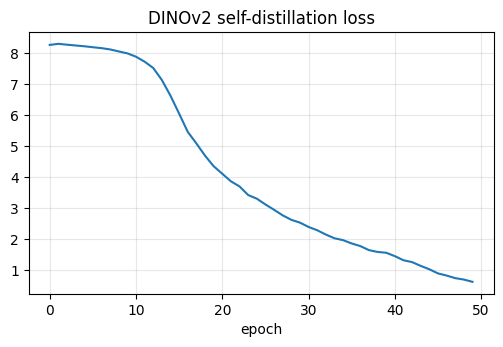

In [5]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers"], check=False)
from transformers import Dinov2Model
GRID = IMG_SIZE // 14                     # 224/14 = 16 -> 16x16 tokens
EMBED = 384
def load_dinov2():
    try:    return Dinov2Model.from_pretrained("facebook/dinov2-small")
    except Exception as e:
        print("download failed, using random init:", e)
        from transformers import Dinov2Config
        return Dinov2Model(Dinov2Config(image_size=IMG_SIZE, patch_size=14, hidden_size=EMBED,
                                        num_hidden_layers=12, num_attention_heads=6, intermediate_size=1536))
# --- DINO heads + multi-crop ---
class DINOHead(nn.Module):
    # NOTE: the original DINO uses weight_norm on the last layer. We use a plain Linear because
    # weight_norm creates non-leaf tensors that break copy.deepcopy when building the EMA teacher
    # (pytorch/pytorch#103001). The L2-normalised bottleneck below preserves the intended behaviour.
    def __init__(s, i, o=2048, k=4096):
        super().__init__(); s.mlp = nn.Sequential(nn.Linear(i,o), nn.GELU(), nn.Linear(o,o), nn.GELU(), nn.Linear(o,256))
        s.last = nn.Linear(256, k, bias=False)
    def forward(s, x): x = F.normalize(s.mlp(x), dim=-1); return s.last(x)
def cls_feat(enc, x): return enc(pixel_values=x).last_hidden_state[:, 0]     # CLS token
gtf = T.Compose([T.RandomResizedCrop(IMG_SIZE, scale=(0.4,1.0), antialias=True), T.RandomHorizontalFlip(0.5),
                 T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
ltf = T.Compose([T.RandomResizedCrop(7*14, scale=(0.05,0.4), antialias=True), T.RandomHorizontalFlip(0.5),
                 T.ToTensor(), T.Normalize(IMAGENET_MEAN, IMAGENET_STD)])
class MultiCrop(Dataset):
    def __init__(s, recs): s.recs = recs
    def __len__(s): return len(s.recs)
    def __getitem__(s, i):
        im = Image.open(PATH_BY_NAME[s.recs[i]["image"]]).convert("RGB")
        return [gtf(im), gtf(im)], [ltf(im), ltf(im)]
def collate(b): return [torch.stack([x[0][j] for x in b]) for j in range(2)], [torch.stack([x[1][j] for x in b]) for j in range(2)]
ssl_loader = DataLoader(MultiCrop(train_recs), batch_size=32, shuffle=True, num_workers=2, drop_last=True, collate_fn=collate)

SSL_EPOCHS = 50; tau = 0.996; tps, tpt = 0.1, 0.04
K_PROTO = 4096
student_enc = load_dinov2().to(DEVICE); teacher_enc = copy.deepcopy(student_enc)
student_head = DINOHead(EMBED, k=K_PROTO).to(DEVICE)
teacher_head = DINOHead(EMBED, k=K_PROTO).to(DEVICE)          # fresh instance + copy weights (deepcopy-safe)
teacher_head.load_state_dict(student_head.state_dict())
for p in list(teacher_enc.parameters())+list(teacher_head.parameters()): p.requires_grad_(False)
center = torch.zeros(1, K_PROTO, device=DEVICE)
opt = torch.optim.AdamW(list(student_enc.parameters())+list(student_head.parameters()), lr=5e-5, weight_decay=4e-2)
ssl_hist = []; t0 = time.time()
for ep in range(1, SSL_EPOCHS+1):
    student_enc.train(); run = 0.0; nb = 0
    for globals_, locals_ in ssl_loader:
        gl = [g.to(DEVICE) for g in globals_]; lo = [l.to(DEVICE) for l in locals_]
        with torch.no_grad():
            t_out = torch.stack([teacher_head(cls_feat(teacher_enc, g)) for g in gl]).float()  # [2,B,K] float32
            t_prob = F.softmax((t_out - center) / tpt, dim=-1)
            center = 0.9*center + 0.1*t_out.mean((0,1), keepdim=True)[0]
        opt.zero_grad(set_to_none=True)
        with amp_ctx():
            s_out = [student_head(cls_feat(student_enc, v)) for v in (gl + lo)]               # all crops
        # cross-entropy in float32 (AMP stability: /0.1 temperature + log-softmax overflow in fp16)
        with torch.autocast(device_type="cuda", enabled=False):
            loss = 0.0; n = 0
            for ti in range(2):
                for si, s in enumerate(s_out):
                    if si == ti: continue
                    loss = loss - (t_prob[ti] * F.log_softmax(s.float() / tps, dim=-1)).sum(-1).mean(); n += 1
            loss = loss / n
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        with torch.no_grad():
            for o, t in zip(student_enc.parameters(), teacher_enc.parameters()): t.mul_(tau).add_(o, alpha=1-tau)
            for o, t in zip(student_head.parameters(), teacher_head.parameters()): t.mul_(tau).add_(o, alpha=1-tau)
        run += float(loss); nb += 1
    ssl_hist.append(run/max(nb,1))
    if ep % 5 == 0 or ep == 1: print(f"  SSL ep {ep:02d} DINO {ssl_hist[-1]:.4f}")
ssl_minutes = (time.time()-t0)/60
print(f"DINOv2 continued pretraining done: {ssl_minutes:.1f} min ({ssl_minutes/SSL_EPOCHS:.2f} min/ep)")
plt.figure(figsize=(6,3.4)); plt.plot(ssl_hist); plt.title("DINOv2 self-distillation loss"); plt.xlabel("epoch"); plt.grid(alpha=.3)
plt.savefig(WORK/"DINOv2_pretrain_loss.png", dpi=110); plt.show()
pretrained_encoder = student_enc

In [6]:
# ---- ViT adapter (tokens -> 2D grid) + DeepLabV3-style ASPP head ----
class ASPPConv(nn.Sequential):
    def __init__(s, i, o, r): super().__init__(nn.Conv2d(i, o, 3, padding=r, dilation=r, bias=False), nn.BatchNorm2d(o), nn.ReLU())
class ASPPPool(nn.Module):
    def __init__(s, i, o): super().__init__(); s.g = nn.AdaptiveAvgPool2d(1); s.c = nn.Sequential(nn.Conv2d(i, o, 1, bias=False), nn.BatchNorm2d(o), nn.ReLU())
    def forward(s, x): return F.interpolate(s.c(s.g(x)), size=x.shape[-2:], mode="bilinear", align_corners=False)
class ASPPHead(nn.Module):
    def __init__(s, i, n, o=256, rates=(1, 3, 6, 9)):
        super().__init__()
        s.br = nn.ModuleList([nn.Sequential(nn.Conv2d(i, o, 1, bias=False), nn.BatchNorm2d(o), nn.ReLU())]
                             + [ASPPConv(i, o, r) for r in rates[1:]] + [ASPPPool(i, o)])
        s.proj = nn.Sequential(nn.Conv2d(o*(len(rates)+1), o, 1, bias=False), nn.BatchNorm2d(o), nn.ReLU(), nn.Dropout(0.1))
        s.cls = nn.Conv2d(o, n, 1)
    def forward(s, x): return s.cls(s.proj(torch.cat([b(x) for b in s.br], 1)))

class ViTSeg(nn.Module):
    def __init__(s, encoder, embed_dim, grid, n, frozen=False):
        super().__init__(); s.encoder = encoder; s.grid = grid; s.head = ASPPHead(embed_dim, n)
        if frozen:
            for p in s.encoder.parameters(): p.requires_grad_(False)
    def forward(s, x):
        H, W = x.shape[-2:]
        tok = s.encoder(pixel_values=x).last_hidden_state[:, 1:, :]   # drop CLS -> [B, N, D]
        B, N, D = tok.shape; h, w = s.grid
        feat = tok.transpose(1, 2).reshape(B, D, h, w)                # ADAPTER: tokens -> 2-D grid
        return F.interpolate(s.head(feat), size=(H, W), mode="bilinear", align_corners=False)
def _is_encoder(name): return name.startswith("encoder.")
def seg_logits(model, x): return model(x)
def seg_train_forward(model, x, y): lo = model(x); return criterion(lo, y), lo

In [7]:
# ---- fine-tune (val split, 50 ep) · monitor test crack-IoU · checkpoint best ----
FT_EPOCHS = 50
def finetune(model, tag, enc_lr, dec_lr):
    enc_params = [p for n, p in model.named_parameters() if p.requires_grad and _is_encoder(n)]
    dec_params = [p for n, p in model.named_parameters() if p.requires_grad and not _is_encoder(n)]
    opt = torch.optim.AdamW([{"params": enc_params, "lr": enc_lr}, {"params": dec_params, "lr": dec_lr}], weight_decay=1e-2)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FT_EPOCHS)
    hist = defaultdict(list); best = -1; best_state = None; t0 = time.time()
    for ep in range(1, FT_EPOCHS+1):
        model.train(); run = 0.0
        for x, y, _ in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE); opt.zero_grad(set_to_none=True)
            with amp_ctx(): loss, _ = seg_train_forward(model, x, y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); run += loss.item()*x.size(0)
        sch.step()
        cm = ConfMat(NUM_CLASSES); model.eval(); vl = 0.0
        with torch.no_grad():
            for x, y, _ in test_loader:
                x = x.to(DEVICE)
                with amp_ctx(): lo = seg_logits(model, x)
                vl += criterion(lo, y.to(DEVICE)).item()*x.size(0); cm.update(lo.argmax(1).cpu(), y)
        met = cm.compute(); ci = met["iou"][1]
        hist["train_loss"].append(run/len(val_recs)); hist["test_loss"].append(vl/len(test_recs))
        hist["test_miou"].append(met["miou"]); hist["test_crack_iou"].append(ci)
        if ci > best: best = ci; best_ep = ep; best_state = copy.deepcopy(model.state_dict())
        if ep % 5 == 0 or ep == 1:
            print(f"  [{tag}] ep {ep:02d} train {hist['train_loss'][-1]:.3f} | test mIoU {met['miou']:.3f} crackIoU {ci:.3f}")
    model.load_state_dict(best_state)
    mins = (time.time()-t0)/60
    print(f"  [{tag}] done {mins:.1f} min | best test crack-IoU {best:.4f} @ ep {best_ep}")
    return model, hist, mins, best_ep

In [8]:
# ---- Task E (test metrics + confusion) + Task F (worst) + results.json ----
def evaluate_and_report(model, hist, mins, best_ep, tag="DINOv2"):
    cm = ConfMat(NUM_CLASSES); per = {}; model.eval()
    rec = {r["sample_id"]: r for r in test_recs}
    with torch.no_grad():
        for x, y, sids in test_loader:
            x = x.to(DEVICE)
            with amp_ctx(): pr = seg_logits(model, x).argmax(1).cpu()
            cm.update(pr, y)
            for b in range(x.size(0)): per[sids[b]] = per_image_iou(pr[b], y[b], 1)
    met = cm.compute()
    print(f"=== Task E — {tag} ===  mIoU {met['miou']:.4f} | crackIoU {met['iou'][1]:.4f} | "
          f"pixAcc {met['pixel_acc']:.4f} | Dice {met['mdice']:.4f}")
    # curves
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(hist["train_loss"], label="fine-tune loss (val)"); ax[0].plot(hist["test_loss"], label="monitor loss (test)")
    ax[0].set_title(f"{tag} loss"); ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(hist["test_miou"], label="test mIoU"); ax[1].plot(hist["test_crack_iou"], label="test crack IoU")
    ax[1].set_title("downstream monitoring"); ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.savefig(WORK/f"{tag}_curves.png", dpi=110, bbox_inches="tight"); plt.show()
    # confusion
    M = cm.mat.numpy()
    plt.figure(figsize=(4,3.4)); plt.imshow(M, cmap="Blues")
    for r_ in range(2):
        for c_ in range(2): plt.text(c_, r_, M[r_,c_], ha="center", va="center")
    plt.xticks([0,1], CLASS_NAMES); plt.yticks([0,1], CLASS_NAMES); plt.xlabel("pred"); plt.ylabel("true")
    plt.title(f"{tag} confusion"); plt.tight_layout(); plt.savefig(WORK/f"{tag}_confusion.png", dpi=110); plt.show()
    # Task F worst
    valid = {k: v for k, v in per.items() if not math.isnan(v)}
    worst = sorted(valid, key=valid.get)[:6]
    fig, ax = plt.subplots(len(worst), 3, figsize=(9, 3*len(worst))); ax = np.atleast_2d(ax)
    for i, sid in enumerate(worst):
        r = rec[sid]; img = np.array(Image.open(PATH_BY_NAME[r["image"]]).convert("RGB"))
        gt = (np.array(Image.open(MASK_BY_NAME[r["mask"]])) > 0).astype(np.uint8)
        x = test_tf(image=img, mask=gt)["image"].unsqueeze(0).to(DEVICE)
        with torch.no_grad(), amp_ctx(): pr = seg_logits(model, x).argmax(1)[0].cpu().numpy()
        ax[i,0].imshow(img); ax[i,0].set_title(f"{sid} IoU={valid[sid]:.2f}", fontsize=8)
        ax[i,1].imshow(cv2.resize(gt,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_NEAREST), cmap="gray"); ax[i,1].set_title("GT", fontsize=8)
        ax[i,2].imshow(pr, cmap="gray"); ax[i,2].set_title("pred", fontsize=8)
        for a in ax[i]: a.axis("off")
    plt.suptitle(f"Task F — worst test images · {tag}", y=1.005); plt.tight_layout()
    plt.savefig(WORK/f"{tag}_worst.png", dpi=100); plt.show()
    # results.json (merge)
    rp = WORK/"results_partB.json"; res = json.load(open(rp)) if rp.exists() else {}
    res[tag] = dict(method=tag, params_M=round(sum(p.numel() for p in model.parameters())/1e6, 2), miou=met["miou"], per_class_iou=met["iou"],
                    pixel_acc=met["pixel_acc"], mdice=met["mdice"], crack_iou=met["iou"][1], crack_dice=met["dice"][1],
                    finetune_minutes=round(mins,1), best_epoch=int(best_ep), n_labelled=len(val_recs),
                    per_image_crack_iou=valid, confusion=cm.mat.tolist())
    json.dump(res, open(rp, "w"), indent=2)
    print("results_partB.json now has:", list(res.keys())); return met

  [DINOv2] ep 01 train 0.944 | test mIoU 0.642 crackIoU 0.411
  [DINOv2] ep 05 train 0.585 | test mIoU 0.638 crackIoU 0.420
  [DINOv2] ep 10 train 0.522 | test mIoU 0.696 crackIoU 0.492
  [DINOv2] ep 15 train 0.470 | test mIoU 0.703 crackIoU 0.504
  [DINOv2] ep 20 train 0.444 | test mIoU 0.713 crackIoU 0.517
  [DINOv2] ep 25 train 0.429 | test mIoU 0.699 crackIoU 0.500
  [DINOv2] ep 30 train 0.408 | test mIoU 0.701 crackIoU 0.502
  [DINOv2] ep 35 train 0.407 | test mIoU 0.705 crackIoU 0.507
  [DINOv2] ep 40 train 0.396 | test mIoU 0.712 crackIoU 0.517
  [DINOv2] ep 45 train 0.388 | test mIoU 0.713 crackIoU 0.518
  [DINOv2] ep 50 train 0.391 | test mIoU 0.707 crackIoU 0.511
  [DINOv2] done 2.6 min | best test crack-IoU 0.5181 @ ep 45
=== Task E — DINOv2 ===  mIoU 0.7128 | crackIoU 0.5181 | pixAcc 0.9159 | Dice 0.8170


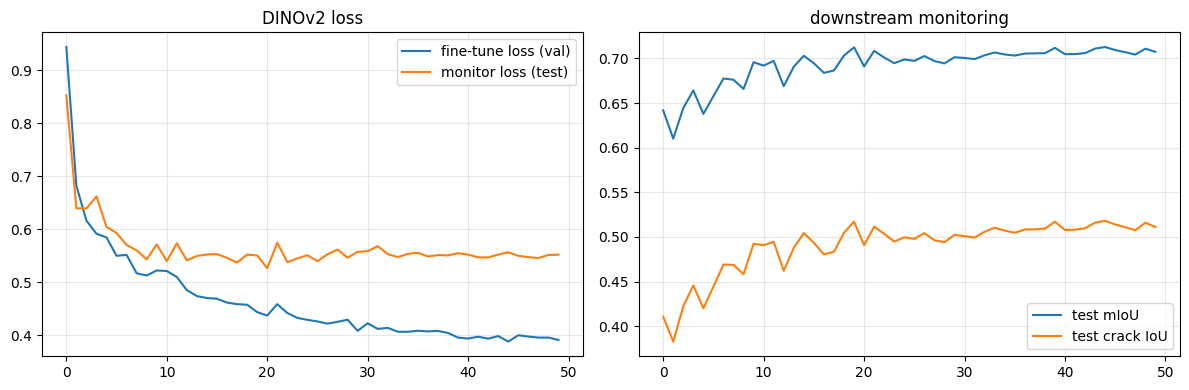

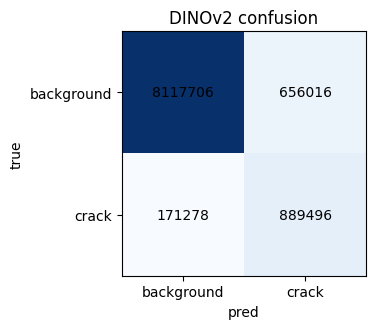

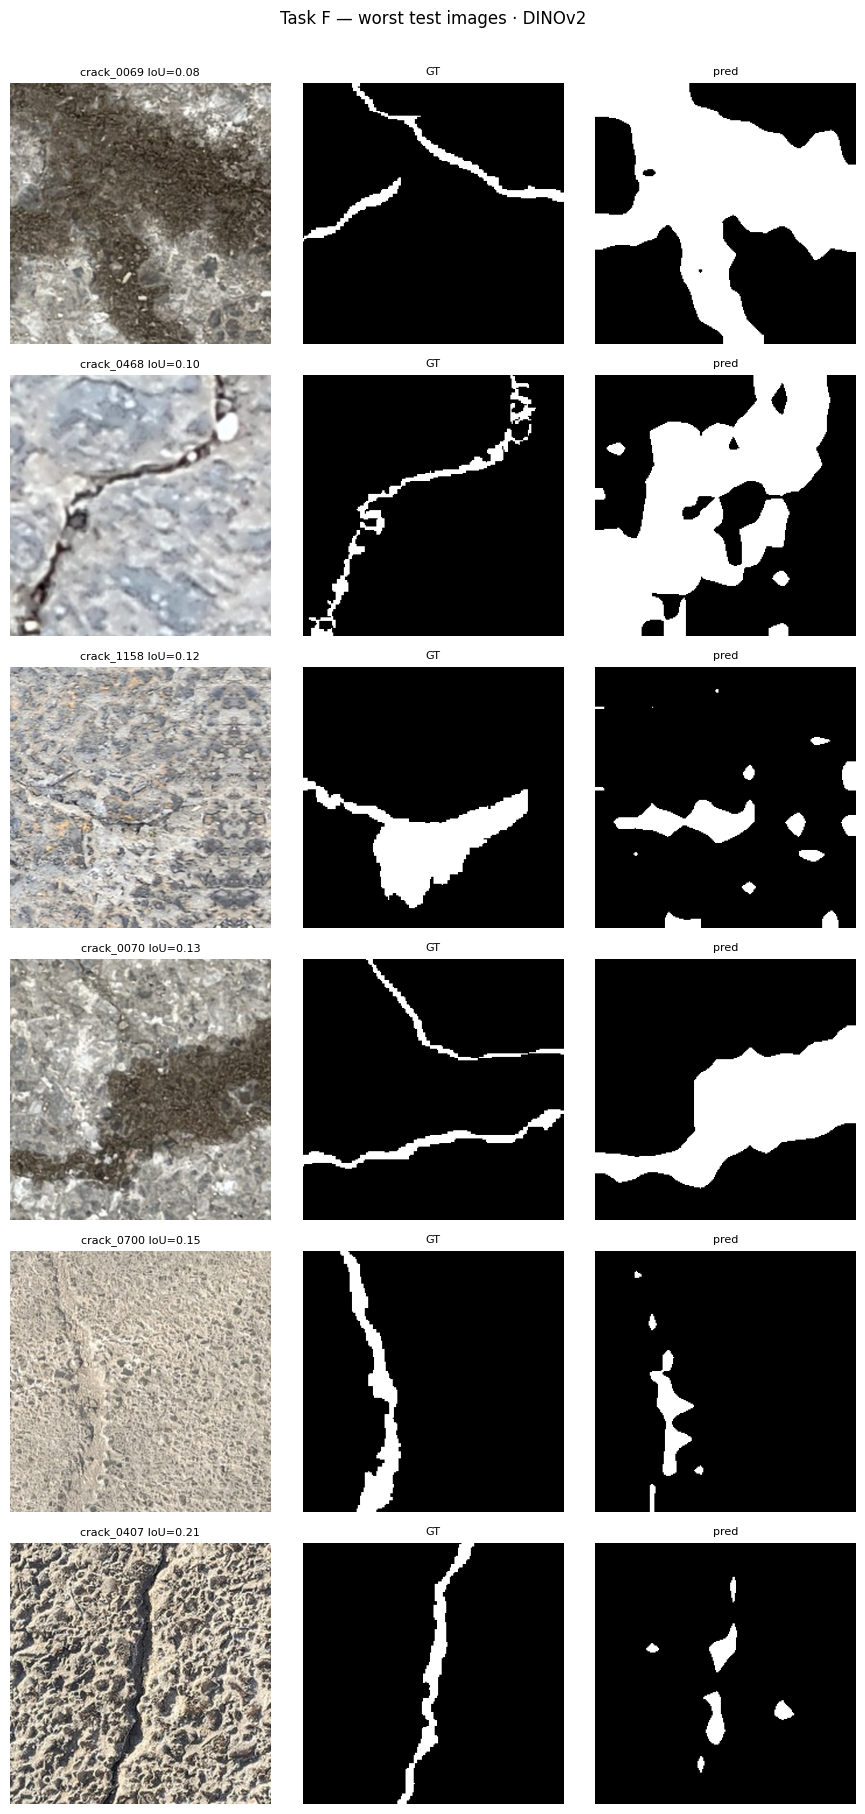

results_partB.json now has: ['DINOv2']


{'iou': [0.9075132476243711, 0.5181157858561618],
 'miou': 0.7128145167402664,
 'dice': [0.951514490140075, 0.6825774301055219],
 'mdice': 0.8170459601227984,
 'pixel_acc': 0.9158783530950646,
 'mean_pixel_acc': 0.8818821666775201}

In [9]:
# ---- attach adapter + ASPP head; full fine-tune (differential LR) ----
model = ViTSeg(pretrained_encoder, EMBED, (GRID, GRID), NUM_CLASSES, frozen=False).to(DEVICE)
model, hist, mins, best_ep = finetune(model, "DINOv2", enc_lr=1e-5, dec_lr=1e-3)
evaluate_and_report(model, hist, mins, best_ep, tag="DINOv2")

## DINOv2 complete
SSL pretraining (50 ep) + downstream fine-tuning (50 ep on 195 labelled images) done; test metrics + worst-image
error analysis produced; appended to `results_partB.json`. **Commit** so the final-comparison notebook can pull it.